# Projeto Prático: Análise Exploratória de Dados

## Tema do projeto
Diabetes nos Estados Unidos.

## Problema principal
O objetivo deste trabalho é entender quais fatores do estilo de vida e da condição de saúde aparecem mais relacionados ao diabetes a partir da base `BRFSS 2015`.

## Fonte e unidade de análise
- fonte: [Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)
- cada linha do dataset representa uma pessoa
- tamanho original da base: aproximadamente `253 mil respostas`
- tamanho da base após limpeza de duplicatas: `229.781` linhas

## 1. Carregamento e pré-processamento

Antes de começar a análise, foi feita uma preparação da base para evitar distorções nos resultados.

Nesta etapa, os cuidados principais foram:
- leitura do CSV por caminho relativo, sem upload manual do Colab
- identificação de valores nulos
- identificação e remoção de linhas duplicadas
- conversão dos campos para tipos numéricos consistentes
- criação da variável auxiliar `diabetes` para apoiar comparações binárias

A análise final passa a usar a **base limpa**, depois da remoção das duplicatas encontradas no dataset.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:.2f}".format

ARQUIVO_DADOS = Path("diabetes_012_health_indicators_BRFSS2015.csv")

# Carrega a base original a partir do arquivo CSV do projeto.
df = pd.read_csv(ARQUIVO_DADOS)
linhas_originais, colunas_originais = df.shape

# Diagnostica valores ausentes e linhas repetidas antes de qualquer tratamento.
nulos_por_coluna = df.isnull().sum()
duplicadas = int(df.duplicated().sum())

# Remove duplicatas exatas para evitar contagem repetida dos mesmos registros.
df = df.drop_duplicates().copy()
linhas_limpas, colunas_limpas = df.shape

# Converte todas as colunas para tipo numérico e padroniza inteiros quando possível.
df[df.columns] = df.apply(pd.to_numeric, errors="raise")
colunas_inteiras = [col for col in df.columns if ((df[col] % 1) == 0).all()]
df[colunas_inteiras] = df[colunas_inteiras].astype(int)

# Cria uma variável auxiliar binária para comparar presença de diabetes.
df["diabetes"] = (df["Diabetes_012"] == 2).astype(int)

distribuicao_classes = (
    df["Diabetes_012"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename({0: "Sem diabetes", 1: "Pré-diabetes", 2: "Diabetes"})
    .to_frame("percentual")
)

print(f"Arquivo carregado: {ARQUIVO_DADOS.name}")
print(f"Dimensão original da base: {linhas_originais:,} linhas x {colunas_originais} colunas")
print(f"Valores nulos totais: {int(nulos_por_coluna.sum())}")
print(f"Linhas duplicadas removidas: {duplicadas:,}")
print(f"Dimensão após limpeza: {linhas_limpas:,} linhas x {colunas_limpas + 1} colunas")
print(f"Duplicatas restantes após limpeza: {int(df.duplicated().sum())}")

print("\nValores nulos por coluna:")
display(nulos_por_coluna.to_frame("nulos"))

print("\nDistribuição percentual das classes:")
display(distribuicao_classes.round(2))

print("\nTipos finais das colunas:")
display(df.dtypes.to_frame("tipo"))

Arquivo carregado: diabetes_012_health_indicators_BRFSS2015.csv
Dimensão original da base: 253,680 linhas x 22 colunas
Valores nulos totais: 0
Linhas duplicadas removidas: 23,899
Dimensão após limpeza: 229,781 linhas x 23 colunas
Duplicatas restantes após limpeza: 0

Valores nulos por coluna:


,nulos
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0



Distribuição percentual das classes:


,percentual
Diabetes_012,
Sem diabetes,82.71
Pré-diabetes,2.01
Diabetes,15.27



Tipos finais das colunas:


,tipo
Diabetes_012,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64


### Correção aplicada na base

A principal correção feita na base foi a remoção de registros duplicados:
- remoção de `23.899` linhas duplicadas, o que corresponde a cerca de `9,4%` do dataset original
- redução da base de `253.680` para `229.781` registros válidos para análise

Mesmo depois da limpeza, ainda existe um ponto que merece atenção: o desequilíbrio entre as classes, com `82,71%` sem diabetes, `2,01%` pré-diabetes e `15,27%` com diabetes.

### Visão rápida da base

A tabela abaixo serve para conferir como os dados ficaram organizados depois da limpeza e quais variáveis serão usadas ao longo da análise.

In [2]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,diabetes
0,0,1,1,1,40,1,0,0,0,0,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,0,25,1,0,0,1,0,...,1,3,0,0,0,0,7,6,1,0
2,0,1,1,1,28,0,0,0,0,1,...,1,5,30,30,1,0,9,4,8,0
3,0,1,0,1,27,0,0,0,1,1,...,0,2,0,0,0,0,11,3,6,0
4,0,1,1,1,24,0,0,0,1,1,...,0,2,3,0,0,0,11,5,4,0


## 2. Estatísticas descritivas e correlação

Depois da limpeza, o próximo passo é resumir o comportamento da base com algumas medidas estatísticas e observar como as variáveis se relacionam entre si.

Nesta parte, foram usados:
- medidas de centralização: média, mediana e moda
- medidas de posição: quartis
- medidas de dispersão: variância, desvio padrão e amplitude
- correlação de Pearson entre variáveis
- normalização Min-Max do IMC para comparar escalas diferentes

Justificativa da normalização:
- o `BMI` possui faixa numérica maior do que variáveis binárias como `HighBP` e `PhysActivity`
- a transformação Min-Max coloca o IMC em escala de `0` a `1`, o que facilita comparar tendências sem alterar a ordem dos valores

In [3]:
def resumo_estatistico(serie):
    return pd.Series(
        {
            "média": serie.mean(),
            "mediana": serie.median(),
            "moda": serie.mode().iloc[0],
            "Q1": serie.quantile(0.25),
            "Q3": serie.quantile(0.75),
            "variância": serie.var(),
            "desvio padrão": serie.std(),
            "amplitude": serie.max() - serie.min(),
        }
    )

bmi_stats = df.groupby("Diabetes_012")["BMI"].apply(resumo_estatistico).unstack()

corr_diabetes = (
    df.drop(columns=["diabetes"])
    .corr(numeric_only=True)["Diabetes_012"]
    .drop("Diabetes_012")
    .sort_values(key=abs, ascending=False)
)

# Normaliza o IMC para comparar uma variável de escala ampla com outras de escala menor.
df["BMI_MinMax"] = (df["BMI"] - df["BMI"].min()) / (df["BMI"].max() - df["BMI"].min())

print("Resumo estatístico do BMI por grupo:")
display(bmi_stats.round(2))

print("\nCorrelações de Pearson com Diabetes_012:")
display(corr_diabetes.head(8).round(3).to_frame("correlação"))

print("\nMédia do BMI normalizado por grupo:")
display(df.groupby("Diabetes_012")["BMI_MinMax"].mean().round(3).to_frame("BMI_MinMax"))

grafico1 = pd.DataFrame(
    {
        "Sem o fator": [
            df.loc[df["HighBP"] == 0, "diabetes"].mean() * 100,
            df.loc[df["HighChol"] == 0, "diabetes"].mean() * 100,
        ],
        "Com o fator": [
            df.loc[df["HighBP"] == 1, "diabetes"].mean() * 100,
            df.loc[df["HighChol"] == 1, "diabetes"].mean() * 100,
        ],
    },
    index=["Pressão Alta", "Colesterol Alto"],
)

grafico3 = df.groupby(["Education", "Income"])["diabetes"].mean().unstack() * 100

grafico4 = (
    df.groupby(["Income", "Sex"])["diabetes"]
    .mean()
    .reset_index()
    .sort_values(["Income", "Sex"])
)
grafico4["diabetes_pct"] = grafico4["diabetes"] * 100

Resumo estatístico do BMI por grupo:


,média,mediana,moda,Q1,Q3,variância,desvio padrão,amplitude
Diabetes_012,,,,,,,,
0,28.03,27.00,27.00,24.00,31.00,41.93,6.47,86.00
1,30.73,30.00,27.00,26.00,34.00,48.52,6.97,83.00
2,31.96,31.00,27.00,27.00,36.00,54.47,7.38,85.00



Correlações de Pearson com Diabetes_012:


,correlação
GenHlth,0.28
HighBP,0.26
BMI,0.21
DiffWalk,0.21
HighChol,0.20
Age,0.18
HeartDiseaseorAttack,0.17
PhysHlth,0.16



Média do BMI normalizado por grupo:


,BMI_MinMax
Diabetes_012,
0,0.19
1,0.22
2,0.23


## 3. Hipótese 1: fatores de risco mais relacionados ao diabetes

**Pergunta:** Quais fatores de risco estão mais relacionados ao diabetes?

**Leitura inicial na base limpa:**
- pressão alta: o percentual de diabetes sobe de `6,93%` para `25,29%`
- colesterol alto: o percentual de diabetes sobe de `9,04%` para `23,15%`
- os dois fatores aparecem com associação clara ao diabetes
- conclusão da hipótese: **confirmada**

Como se trata de um dataset observacional, o termo mais adequado aqui é **associação**, e não causa direta.

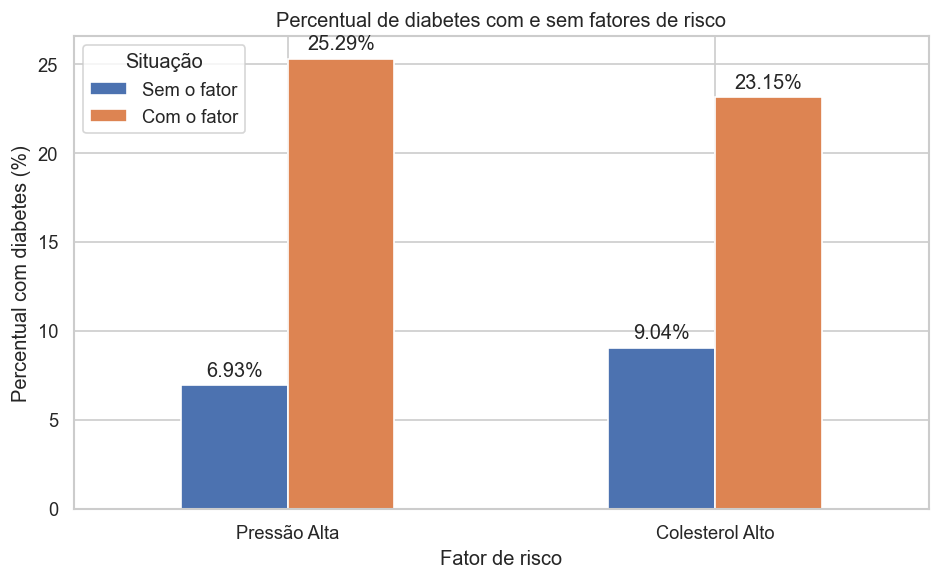

In [4]:
ax = grafico1.plot(kind="bar", figsize=(8, 5), rot=0)

ax.set_title("Percentual de diabetes com e sem fatores de risco")
ax.set_xlabel("Fator de risco")
ax.set_ylabel("Percentual com diabetes (%)")
ax.legend(title="Situação")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

## 4. Hipótese 2: IMC, atividade física e diabetes

**Pergunta:** Qual a relação entre IMC, atividade física e diabetes?

**Pontos principais na base limpa:**
- o IMC médio cresce de `28,03` para `30,73` e `31,96` conforme o grupo avança
- a prática de atividade física cai de `75,41%` no grupo sem diabetes para `62,85%` no grupo com diabetes
- o boxplot e as correlações reforçam essa tendência
- conclusão da hipótese: **confirmada**

Os resultados mostram uma **relação observada** entre as variáveis, sem indicar causalidade direta.

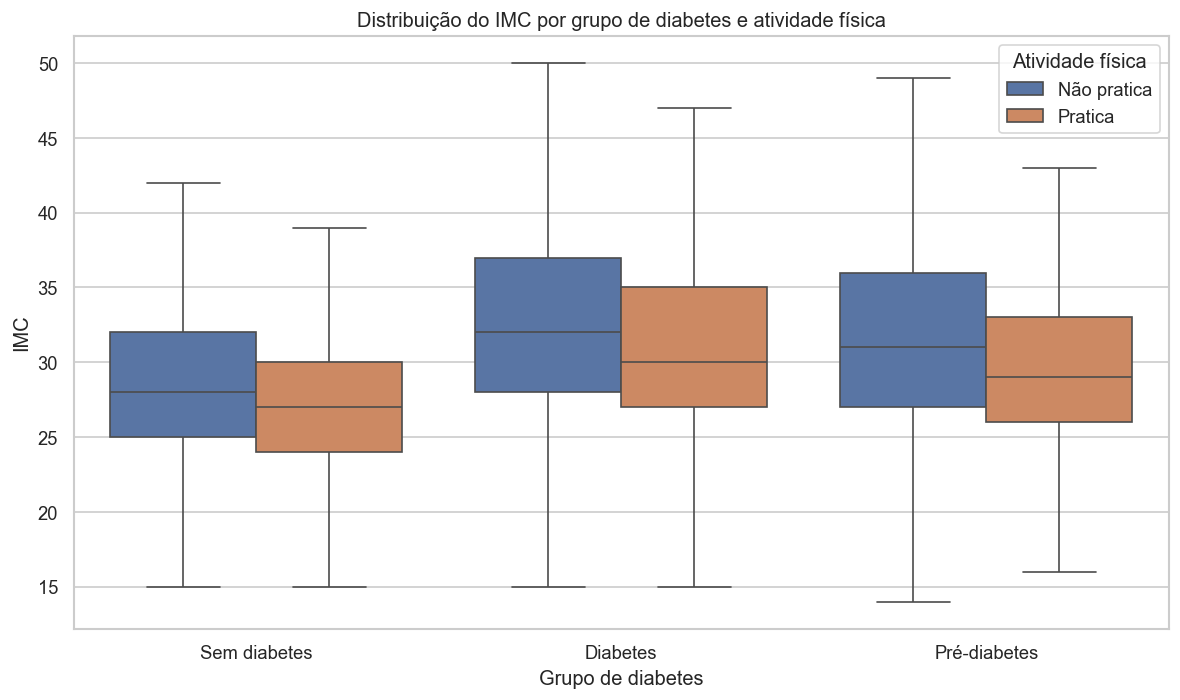

Coeficientes de correlação de Pearson:
BMI x Diabetes_012: 0.212
PhysActivity x Diabetes_012: -0.103
BMI x PhysActivity: -0.128

Percentual de atividade física por grupo de diabetes:


PhysActivity,0,1
Diabetes_012,,
0,24.59,75.41
1,32.17,67.83
2,37.15,62.85



Resumo dos outliers de BMI por grupo de diabetes:


,Grupo_Diabetes,Q1,Q3,IQR,Limite_Inferior,Limite_Superior,Quantidade_Outliers
0,0,24.00,31.00,7.00,13.50,41.50,6186
1,1,26.00,34.00,8.00,14.00,46.00,123
2,2,27.00,36.00,9.00,13.50,49.50,853


In [5]:
grafico2_plot = df[["Diabetes_012", "BMI", "PhysActivity"]].copy()
grafico2_plot["Grupo de diabetes"] = grafico2_plot["Diabetes_012"].map(
    {0: "Sem diabetes", 1: "Pré-diabetes", 2: "Diabetes"}
)
grafico2_plot["Atividade física"] = grafico2_plot["PhysActivity"].map(
    {0: "Não pratica", 1: "Pratica"}
)

plt.figure(figsize=(10, 6))
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=PendingDeprecationWarning)
    ax = sns.boxplot(
        data=grafico2_plot,
        x="Grupo de diabetes",
        y="BMI",
        hue="Atividade física",
        showfliers=False,
    )
ax.set_title("Distribuição do IMC por grupo de diabetes e atividade física")
ax.set_xlabel("Grupo de diabetes")
ax.set_ylabel("IMC")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Atividade física")

plt.tight_layout()
plt.show()

atividade_por_grupo = pd.crosstab(
    df["Diabetes_012"], df["PhysActivity"], normalize="index"
) * 100

corr_bmi_diabetes = df["BMI"].corr(df["Diabetes_012"], method="pearson")
corr_phys_diabetes = df["PhysActivity"].corr(df["Diabetes_012"], method="pearson")
corr_bmi_phys = df["BMI"].corr(df["PhysActivity"], method="pearson")

outliers_lista = []
for grupo in sorted(df["Diabetes_012"].unique()):
    dados_grupo = df.loc[df["Diabetes_012"] == grupo, "BMI"]
    q1 = dados_grupo.quantile(0.25)
    q3 = dados_grupo.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = dados_grupo[
        (dados_grupo < limite_inferior) | (dados_grupo > limite_superior)
    ]

    outliers_lista.append(
        {
            "Grupo_Diabetes": grupo,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Limite_Inferior": limite_inferior,
            "Limite_Superior": limite_superior,
            "Quantidade_Outliers": int(outliers.count()),
        }
    )

outliers_df = pd.DataFrame(outliers_lista)

print("Coeficientes de correlação de Pearson:")
print(f"BMI x Diabetes_012: {corr_bmi_diabetes:.3f}")
print(f"PhysActivity x Diabetes_012: {corr_phys_diabetes:.3f}")
print(f"BMI x PhysActivity: {corr_bmi_phys:.3f}")

print("\nPercentual de atividade física por grupo de diabetes:")
display(atividade_por_grupo.round(2))

print("\nResumo dos outliers de BMI por grupo de diabetes:")
display(outliers_df.round(2))

## 5. Hipótese 3: renda, educação e diabetes

**Pergunta:** Qual a relação entre educação, renda e diabetes?

**Leitura inicial na base limpa:**
- na menor faixa de renda, o percentual de diabetes foi `24,34%`
- na maior faixa de renda, o percentual caiu para `9,81%`
- no maior nível de educação, o percentual observado foi `11,56%`
- no geral, a tendência continua coerente entre renda, escolaridade e diabetes
- conclusão da hipótese: **confirmada como tendência geral**

Leitura correta das categorias:
- `Income` não representa renda exata em dinheiro; ele representa faixas ordenadas de renda
- `Education` não representa anos exatos de estudo; ele representa níveis crescentes de escolaridade
- por isso, valores maiores nessas colunas indicam níveis mais altos, e a leitura deve ser feita como tendência entre categorias

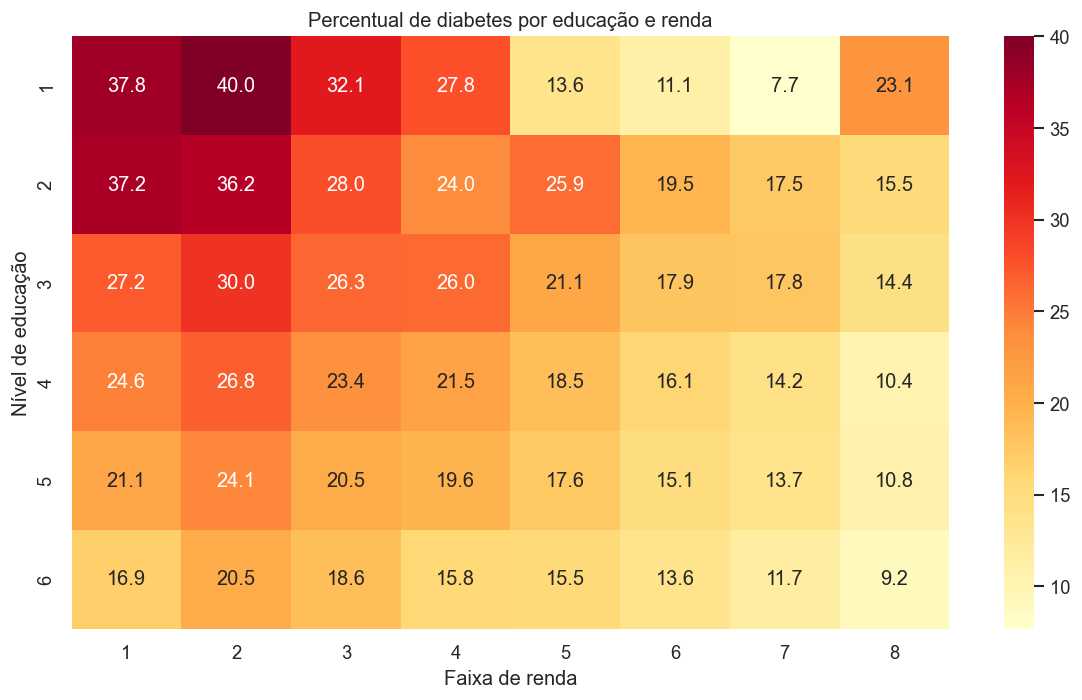

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(grafico3, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Percentual de diabetes por educação e renda")
plt.xlabel("Faixa de renda")
plt.ylabel("Nível de educação")
plt.tight_layout()
plt.show()

## 6. Hipótese 4: sexo, renda e diabetes

**Pergunta:** Qual a relação entre sexo, renda e diabetes?

**Leitura inicial na base limpa:**
- a renda mantém relação inversa com o percentual de diabetes em ambos os sexos
- em várias faixas intermediárias e altas, o percentual masculino aparece maior
- porém, na menor faixa de renda, o percentual feminino (`25,84%`) ficou acima do masculino (`21,18%`)
- conclusão da hipótese: **não confirmada na forma proposta**

Isso significa que a hipótese específica de que **homens de baixa renda** teriam mais tendência ao diabetes **não se confirmou na menor faixa de renda**. O resultado mais seguro é dizer que renda baixa está associada a percentuais maiores de diabetes nos dois grupos.

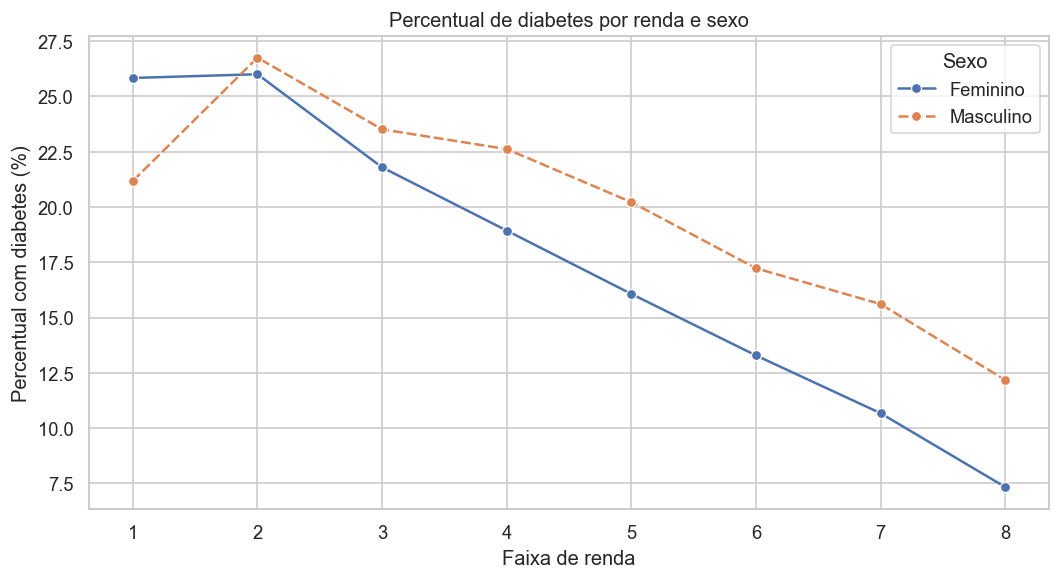

In [7]:
grafico4_plot = grafico4.copy()
grafico4_plot["Sexo"] = grafico4_plot["Sex"].map({0: "Feminino", 1: "Masculino"})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=grafico4_plot,
    x="Income",
    y="diabetes_pct",
    hue="Sexo",
    style="Sexo",
    marker="o",
)
plt.title("Percentual de diabetes por renda e sexo")
plt.xlabel("Faixa de renda")
plt.ylabel("Percentual com diabetes (%)")
plt.tight_layout()
plt.show()

## 7. Conclusões gerais

Ao final da análise, a base ficou mais consistente e os resultados passaram a ficar mais fáceis de interpretar.

Em resumo:
- o pré-processamento removeu `23.899` duplicatas e manteve a análise na base limpa com `229.781` registros
- pressão alta, colesterol alto e IMC elevado apareceram entre os fatores mais associados ao diabetes nesta base
- renda mais baixa e escolaridade mais baixa continuaram associadas a percentuais mais altos de diabetes
- a hipótese 4 não foi confirmada na forma original, porque na menor faixa de renda o percentual feminino ficou acima do masculino

No conjunto, os resultados ajudam a responder às perguntas do grupo de forma clara, mostrando associações consistentes entre saúde, estilo de vida, renda, escolaridade e diabetes.